In [1]:
import os
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

import torch
import numpy as np
from PIL import Image
from transformers import ViTFeatureExtractor, ViTForImageClassification


/home/kodai_sasaki/Video-DS-and-ML/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
model.to(device)
model.eval()

image = Image.open("../../data/image_data/umamusu.jpg").convert("RGB") 
inputs = feature_extractor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

# 6. 結果表示
print(f"Predicted class index: {predicted_class_idx}")
print(f"Predicted label: {model.config.id2label[predicted_class_idx]}")


cuda


/home/kodai_sasaki/Video-DS-and-ML/.venv/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Predicted class index: 917
Predicted label: comic book


In [3]:
from torch import nn
# vitのImageClassifierOutputからlogitだけを返すクラス
# ImageClassifierOutput(loss=None, logits=tensor([...]), hidden_states=None, attentions=None)の形式からlogitsだけを返す
class ImageLogitsOutput(nn.Module):
    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu'):
        super().__init__()
        self.model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")
        self.model.to(device)
        self.device = device

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        inputs = inputs.to(self.device)
        outputs = self.model(pixel_values=inputs)
        logits = outputs.logits
        return logits


In [4]:
from rise import RISE

In [5]:
# help(RISE)

In [6]:
target_input = inputs['pixel_values']
model = ImageLogitsOutput()
explainer = RISE(model)
attr = explainer.attribute(
    target_input,
    n_samples=512,
    batch_size=8,
    show_progress=True,
    target=917,
)


[rise.single]: 100%|██████████| 64/64 [00:01<00:00, 49.79it/s]


In [7]:
from typing import Optional
import matplotlib.pyplot as plt


def _resize_image(
    img_arr: np.ndarray, height: int, width: int, interpolation=Image.BILINEAR
) -> np.ndarray:
    """np.ndarray形式の画像をリサイズする"""
    pil_image = Image.fromarray(img_arr)
    # PILのresizeの引数は(width, height)で、tochvisionとは逆なので注意
    pil_image = pil_image.resize((width, height), resample=interpolation)
    return np.array(pil_image)


def _tick_off(ax):
    ax.tick_params(
        bottom=False,
        left=False,
        right=False,
        top=False,
        labelbottom=False,
        labelleft=False,
        labelright=False,
        labeltop=False,
    )


def show_heatmap(
    image,
    heatmap_value,
    alpha=0.3,
    figsize=(24, 8),
    save_path: Optional[str] = None,
    show_plot=True,
):
    """
    注意: この関数はノートブックから呼ぶことを想定したものです。特にAPIでは使わないでください。
    要因可視化結果を描画する。
    元画像・ヒートマップ・重ねたもの、の3枚を並べて出力する。
    Args:
        image: 画像のnumpy.ndarray
        heatmap_value: 要因可視化結果のnumpy.ndarray
        alpha: 重ね表示におけるheatmapの透過度
        figsize: 画像3枚を並べた全体のサイズ
        save_path: 図の保存先のパス。Noneなら保存しない。保存先のディレクトリは既に存在する必要がある。
        show_plot: plt.show()で図を表示するかどうか。jupyterから呼ぶときに使う。
    """
    plt.figure(figsize=figsize)
    heatmap_resized = _resize_image(heatmap_value, *image.shape[:2])
    lim = np.abs(heatmap_resized).max()

    # 元画像
    ax = plt.subplot(131)
    plt.imshow(image)
    _tick_off(ax)

    # ヒートマップのみ
    ax = plt.subplot(132)
    plt.imshow(image, alpha=0)  # 描画サイズを揃えるため、元画像を見えないようにプロット
    # plt.pcolor(heatmap_resized, cmap='jet')  # pcolorは遅い
    plt.imshow(heatmap_resized, cmap="jet")
    plt.clim(-lim, lim)
    _tick_off(ax)

    ax = plt.subplot(133)
    plt.imshow(image, alpha=1 - alpha)
    # plt.pcolor(heatmap_resized, cmap='jet', alpha=alpha)
    plt.imshow(heatmap_resized, cmap="jet", alpha=alpha)
    plt.clim(-lim, lim)
    _tick_off(ax)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", facecolor="white", pad_inches=0)
    if show_plot:
        plt.show()
    else:
        plt.clf()
        plt.close()


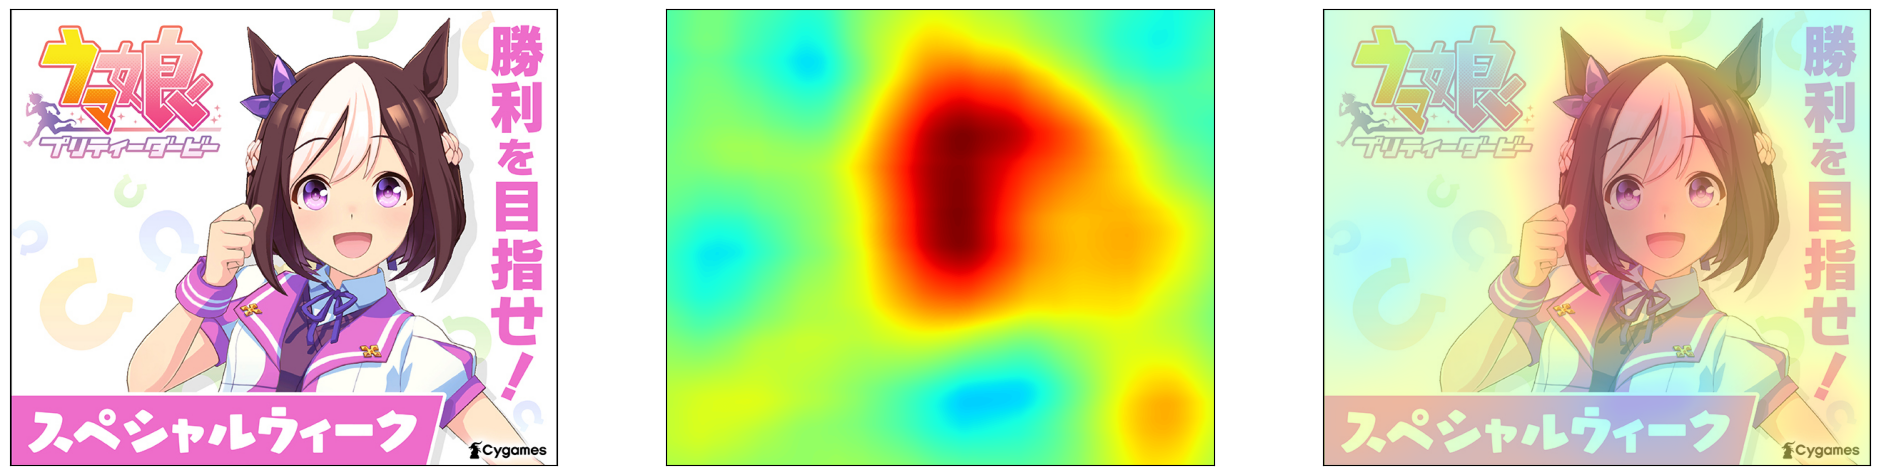

In [8]:
# attr.cpu().numpy()をプロットする

show_heatmap(np.array(image), attr.cpu().numpy()[0])
